In [35]:
import json
import glob
from scipy.stats import hypergeom

In [36]:
# Load background genes
with open("../algorithm_comparison/Cell/background.txt", "r") as f:
    background_set = set(line.strip() for line in f)
print(len(background_set))

12939


In [37]:
# Load from a curated_set
with open("./Cell/curated_set.txt", "r") as f:
    curated_set = set(line.strip() for line in f)
print(len(curated_set))

51


In [38]:
# load target genes
with open("../transition_set/Cell/Nlog_nlog/target_genes.json", 'r') as json_file:
    Nlog_nlog_target_genes = json.load(json_file) 
print(Nlog_nlog_target_genes)

{'targets_I_4S': ['KCTD5', 'BCKDHA', 'MRPL38', 'RNF25', 'IER5', 'VWA5A', 'TIPARP', 'HUNK'], 'targets_III_4S': [], 'targets_IV_4S': ['ING4', 'MED8', 'EIF2B4', 'DMAP1', 'TMEM222', 'FGGY', 'DUSP26', 'DNAJC8', 'HEXIM2', 'TUBB2A', 'HAND1', 'PRKAG1', 'CCNL2', 'SMAGP', 'LRRC42', 'FAM227B', 'ACBD4', 'ZFP36L2', 'RNPEPL1', 'ECHDC3', 'HPCAL4', 'PTPRH', 'DLGAP3', 'C17orf107', 'TRIL', 'GNG5', 'SGPL1', 'CHST1', 'ACHE', 'MAP1LC3A', 'NEIL1', 'RAB3B', 'KCNC4', 'LINC01562'], 'targets_III_I': ['SGSM3', 'AC010894.3', 'SCARA3', 'USP27X', 'PIK3CD-AS2', 'INSM1', 'AP006285.2', 'ATXN7', 'AL365181.2', 'AC159540.1'], 'targets_IV_I': ['TRNAU1AP', 'SERPINE2', 'HMX1', 'MYO1C', 'DOC2B', 'DENND2A', 'TRIOBP', 'TMEM65', 'ARHGEF10L', 'RHOC', 'NACAD', 'KLF13', 'STK11IP', 'RHBDD1', 'SH3PXD2B', 'DNM1', 'WIPF1', 'SLC12A6', 'ARHGAP22', 'CPNE2', 'LIFR', 'PKD1', 'NTRK1', 'HYDIN', 'NMNAT1', 'VSTM4', 'UBE2H', 'GJC3', 'PINK1', 'YPEL3', 'STARD9', 'HAND1', 'LBX2-AS1', 'VSTM2A', 'SPTB', 'F11R', 'SLC31A2', 'CCR6', 'NLRP3', 'GPBAR1', 

In [39]:
# load target genes
with open("../transition_set/Cell/Nlog_reciprocal/target_genes.json", 'r') as json_file:
    Nlog_reciprocal_target_genes = json.load(json_file) 
print(Nlog_reciprocal_target_genes)

{'targets_I_4S': ['BCKDHA', 'ERCC5', 'IER5', 'CALML4', 'TIPARP', 'MYRIP', 'PHF19', 'HUNK'], 'targets_III_4S': ['EPB42', 'PTPRH', 'ASAP3', 'FAM214B', 'ACBD4', 'MAP1LC3B', 'PRKAG1', 'ATP6V1E1', 'HDAC11', 'SMAGP', 'PRR5', 'SMIM10L2B', 'SLC25A45', 'RAB3B', 'MAP1LC3A', 'LINC01562', 'OSTF1', 'RBFOX1', 'SCG2', 'PRKCB', 'RNASEL', 'DNAJB4', 'JMJD1C-AS1', 'LPCAT2', 'SFRP1', 'TG'], 'targets_IV_4S': ['ING4', 'MED8', 'DMAP1', 'FGGY', 'DUSP26', 'DNAJC8', 'HEXIM2', 'TUBB2A', 'HAND1', 'PRKAG1', 'CCNL2', 'PPP1R18', 'SMAGP', 'LRRC42', 'FAM227B', 'ACBD4', 'ZFP36L2', 'RNPEPL1', 'ECHDC3', 'HPCAL4', 'PTPRH', 'DLGAP3', 'C17orf107', 'GNG5', 'SGPL1', 'CHST1', 'ACHE', 'MAP1LC3A', 'NEIL1', 'RAB3B', 'KCNC4', 'LINC01562'], 'targets_III_I': ['UNC119B', 'SCARA3', 'USP27X', 'INSM1', 'HIST1H2AI', 'LINC00864', 'LINC01260', 'AMT', 'SCO2'], 'targets_IV_I': ['TRNAU1AP', 'CD9', 'SERPINE2', 'CLIC1', 'PRKAG2', 'DNER', 'DOC2B', 'CSRP1', 'MGAT4B', 'SNX24', 'KLF13', 'STK11IP', 'RHBDD1', 'WIPF1', 'BST1', 'PKD1', 'HYDIN', 'WSCD1'

In [7]:
# load target genes
with open("../transition_set/Cell/Reciprocal_nlog/target_genes.json", 'r') as json_file:
    Reciprocal_nlog_target_genes = json.load(json_file) 
print(Reciprocal_nlog_target_genes)

{'targets_I_4S': ['KCTD5', 'SLC35A2', 'RGS2', 'ERCC5', 'IER5', 'VWA5A', 'PTPN20'], 'targets_III_4S': ['PTPRH', 'ASAP3', 'FAM214B', 'ACBD4', 'MAP1LC3B', 'PRKAG1', 'HPCAL4', 'HDAC11', 'ARHGEF37', 'SMAGP', 'OAZ3', 'PRR5', 'SMIM10L2B', 'SLC25A45', 'NFATC4', 'RAB3B', 'MAP1LC3A', 'ARPC1B', 'TMIE', 'RBFOX1', 'WNT4', 'RNASEL', 'DNAJB4', 'JMJD1C-AS1', 'POR', 'LPCAT2', 'YPEL3', 'FNDC4', 'SFRP1'], 'targets_IV_4S': ['ING4', 'MED8', 'EIF2B4', 'DMAP1', 'ATP6V0B', 'FGGY', 'DUSP26', 'HEXIM2', 'TUBB2A', 'PRKAG1', 'CCNL2', 'SMAGP', 'LRRC42', 'ELOVL1', 'FAM227B', 'PRKCD', 'RNPEPL1', 'GDPD5', 'HPCAL4', 'PTPRH', 'DLGAP3', 'C17orf107', 'GNG5', 'OAZ3', 'SGPL1', 'MAP1LC3A', 'RAB3B', 'KCNC4', 'LINC01562'], 'targets_III_I': ['LMBR1L', 'SGSM3', 'AC010894.3', 'CLN3', 'ATXN7', 'AL365181.2', 'HIST1H2AI', 'PRICKLE4', 'AC245100.1', 'AC159540.1'], 'targets_IV_I': ['SERPINE2', 'CLIC1', 'TMEM59', 'MBLAC1', 'PECR', 'CSRP1', 'BPHL', 'TMEFF2', 'ABHD15', 'TFEB', 'CYB5R1', 'TPRG1L', 'RNPEPL1', 'TSTD3', 'KCTD1', 'EPHX2', 'SNT

In [8]:
# load target genes
with open("../transition_set/Cell/Reciprocal_reciprocal/target_genes.json", 'r') as json_file:
    Reciprocal_reciprocal_target_genes = json.load(json_file) 
print(Reciprocal_reciprocal_target_genes)

{'targets_I_4S': ['KCTD5', 'ERCC5', 'IER5', 'CALML4', 'PTPN20'], 'targets_III_4S': ['TSC22D4', 'SLC44A4', 'ACTR3C', 'RENBP', 'ERCC5', 'ING4', 'ELMO3', 'ATP2A3', 'CSDC2', 'SCRN2', 'UBXN11', 'ZNF529-AS1', 'LMF2', 'SMAGP', 'GRN', 'GCGR', 'ZBTB42', 'DNAJB5', 'MIAT', 'FGGY', 'INTS6-AS1', 'CCR10', 'FOXP4'], 'targets_IV_4S': ['ING4', 'MED8', 'EIF2B4', 'DMAP1', 'ATP6V0B', 'FGGY', 'DUSP26', 'HEXIM2', 'TUBB2A', 'PRKAG1', 'CCNL2', 'SMAGP', 'LRRC42', 'ELOVL1', 'FAM227B', 'PRKCD', 'RNPEPL1', 'ARHGAP22', 'GDPD5', 'HPCAL4', 'PTPRH', 'DLGAP3', 'C17orf107', 'TRIL', 'GNG5', 'OAZ3', 'SGPL1', 'MAP1LC3A', 'RAB3B', 'KCNC4'], 'targets_III_I': ['LMBR1L', 'HIST1H2AI'], 'targets_IV_I': ['BPHL', 'CYB5R1', 'WIPF1', 'POMC', 'HYDIN', 'NMNAT1', 'VSTM4', 'GJC3', 'YPEL3', 'STAC', 'NPHP1', 'VSTM2A', 'CHD5', 'F11R', 'SLC31A2', 'GCGR', 'PHYHIP', 'NLRP3', 'GPBAR1', 'SMOC1'], 'targets_IV_III': ['GHDC']}


In [10]:
Nlog_nlog_target_list = list()
for i in Nlog_nlog_target_genes:
    Nlog_nlog_target_list += Nlog_nlog_target_genes[i]
Nlog_nlog_target_set = set(Nlog_nlog_target_list)
print(len(Nlog_nlog_target_set))
print(Nlog_nlog_target_set)

95
{'SMAGP', 'CCNL2', 'GPBAR1', 'MRPL38', 'HEXIM2', 'DMAP1', 'MYO1C', 'AP006285.2', 'BCKDHA', 'CHST1', 'GJC3', 'DLGAP3', 'SCARA3', 'TUBB2A', 'C17orf107', 'LBX2-AS1', 'NEIL1', 'PKD1', 'RHOC', 'NDUFA4L2', 'EIF2B4', 'NMNAT1', 'LINC01562', 'AC010894.3', 'IER5', 'RNPEPL1', 'VSTM4', 'HYDIN', 'STK11IP', 'SLC12A6', 'AC159540.1', 'DNAJC8', 'TRIOBP', 'ARHGAP22', 'LRRC42', 'NLRP3', 'FGGY', 'WIPF1', 'MED8', 'TRIL', 'KCTD5', 'NACAD', 'KLF13', 'EVA1B', 'ING4', 'MAP1LC3A', 'RHBDD1', 'ATXN7', 'STARD9', 'VSTM2A', 'UBE2H', 'PTPRH', 'USP27X', 'DENND2A', 'NTRK1', 'HMX1', 'GPSM2', 'F11R', 'FAM227B', 'HPCAL4', 'DNM1', 'HUNK', 'DUSP26', 'SLC31A2', 'RNF25', 'AL365181.2', 'YPEL3', 'KCNC4', 'TIPARP', 'DOC2B', 'CCR6', 'PRKAG1', 'LIFR', 'TRNAU1AP', 'SERPINE2', 'RAB3B', 'GNG5', 'ACBD4', 'PINK1', 'SGPL1', 'VWA5A', 'SPTB', 'ACHE', 'INSM1', 'HAND1', 'CPNE2', 'TMEM222', 'SH3PXD2B', 'TMEM65', 'ECHDC3', 'PIK3CD-AS2', 'ARHGEF10L', 'ZFP36L2', 'GHDC', 'SGSM3'}


In [11]:
with open("./Cell/Nlog_nlog_target_set.txt", 'w') as f:
    for i in Nlog_nlog_target_set:
        f.write(i + '\n')

In [12]:
Nlog_reciprocal_target_list = list()
for i in Nlog_reciprocal_target_genes:
    Nlog_reciprocal_target_list += Nlog_reciprocal_target_genes[i]
Nlog_reciprocal_target_set = set(Nlog_reciprocal_target_list)
print(len(Nlog_reciprocal_target_set))
print(Nlog_reciprocal_target_set)

106
{'SMAGP', 'SCG2', 'DNAJB4', 'JMJD1C-AS1', 'TG', 'SCO2', 'DNER', 'GPBAR1', 'LPCAT2', 'HEXIM2', 'DMAP1', 'BCKDHA', 'CHST1', 'TNFSF15', 'GJC3', 'DLGAP3', 'SCARA3', 'TUBB2A', 'C17orf107', 'LBX2-AS1', 'NEIL1', 'PHF19', 'CLIC1', 'PKD1', 'CSRP1', 'MAP1LC3B', 'PRR5', 'FAM43A', 'DPY19L1', 'NMNAT1', 'LINC01562', 'IER5', 'RNASEL', 'RNPEPL1', 'VSTM4', 'LINC00864', 'PRKAG2', 'HYDIN', 'STK11IP', 'CALML4', 'DNAJC8', 'AMT', 'LRRC42', 'FGGY', 'KIF26B', 'WIPF1', 'MED8', 'ERCC5', 'RBFOX1', 'KLF13', 'MAP1LC3A', 'ING4', 'LINC01260', 'RHBDD1', 'STARD9', 'ITM2C', 'UNC119B', 'VSTM2A', 'DDX58', 'PTPRH', 'BST1', 'USP27X', 'GPSM2', 'F11R', 'FAM227B', 'HPCAL4', 'HUNK', 'DUSP26', 'MGAT4B', 'SLC31A2', 'SNX24', 'YPEL3', 'KCNC4', 'TIPARP', 'WSCD1', 'C1orf226', 'PPP1R18', 'DOC2B', 'PRKAG1', 'HDAC11', 'TRNAU1AP', 'SERPINE2', 'ASAP3', 'RAB3B', 'GNG5', 'NFATC4', 'ACBD4', 'SGPL1', 'SMIM10L2B', 'ACHE', 'INSM1', 'HAND1', 'ATP6V1E1', 'HIST1H2AI', 'OSTF1', 'EPB42', 'SLC25A45', 'SFRP1', 'ECHDC3', 'MYRIP', 'FAM214B', 'CD9',

In [13]:
with open("./Cell/Nlog_reciprocal_target_set.txt", 'w') as f:
    for i in Nlog_reciprocal_target_set:
        f.write(i + '\n')

In [14]:
Reciprocal_nlog_target_list = list()
for i in Reciprocal_nlog_target_genes:
    Reciprocal_nlog_target_list += Reciprocal_nlog_target_genes[i]
Reciprocal_nlog_target_set = set(Reciprocal_nlog_target_list)
print(len(Reciprocal_nlog_target_set))
print(Reciprocal_nlog_target_set)

106
{'SMAGP', 'DNAJB4', 'JMJD1C-AS1', 'CCNL2', 'GPBAR1', 'OAZ3', 'PRKCD', 'MBLAC1', 'LPCAT2', 'HEXIM2', 'DMAP1', 'CLN3', 'DLGAP3', 'POR', 'TUBB2A', 'C17orf107', 'FNDC4', 'PTPN20', 'CLIC1', 'ATP6V0B', 'CSRP1', 'MAP1LC3B', 'PRR5', 'FAM43A', 'ARPC1B', 'DPY19L1', 'EIF2B4', 'LINC01562', 'AC010894.3', 'IER5', 'GDPD5', 'RNASEL', 'RNPEPL1', 'VSTM4', 'BPHL', 'RGS2', 'HYDIN', 'CHD5', 'AC159540.1', 'WNT4', 'TMIE', 'LRRC42', 'FGGY', 'MED8', 'ERCC5', 'KCTD5', 'TMEFF2', 'ABTB1', 'RBFOX1', 'MAP1LC3A', 'ING4', 'TPRG1L', 'ATXN7', 'KCTD1', 'AC245100.1', 'PTPRH', 'ARHGEF37', 'F11R', 'SNTG2', 'HPCAL4', 'FAM227B', 'TSTD3', 'DUSP26', 'GCGR', 'SLC35A2', 'PRICKLE4', 'TMEM59', 'AL365181.2', 'YPEL3', 'KCNC4', 'PRUNE2', 'PRKAG1', 'STAC', 'HDAC11', 'AC144652.1', 'RAP1GAP2', 'PECR', 'GRM4', 'SERPINE2', 'ASAP3', 'RAB3B', 'GNG5', 'NFATC4', 'CYB5R1', 'ACBD4', 'TFEB', 'SGPL1', 'VWA5A', 'SMIM10L2B', 'REEP6', 'EPHX2', 'TAPBP', 'HIST1H2AI', 'SLC25A45', 'SFRP1', 'LMBR1L', 'LINC00926', 'FAM214B', 'NPHP1', 'ABHD15', 'RAB15'

In [15]:
with open("./Cell/Recprocal_nlog_target_set.txt", 'w') as f:
    for i in Reciprocal_nlog_target_set:
        f.write(i + '\n')

In [16]:
Reciprocal_reciprocal_target_list = list()
for i in Reciprocal_reciprocal_target_genes:
    Reciprocal_reciprocal_target_list += Reciprocal_reciprocal_target_genes[i]
Reciprocal_reciprocal_target_set = set(Reciprocal_reciprocal_target_list)
print(len(Reciprocal_reciprocal_target_set))
print(Reciprocal_reciprocal_target_set)

76
{'SMAGP', 'RAB3B', 'DNAJB5', 'GNG5', 'VSTM2A', 'GPBAR1', 'PRKCD', 'OAZ3', 'HYDIN', 'CYB5R1', 'PTPRH', 'CHD5', 'PHYHIP', 'ELMO3', 'LMF2', 'ATP2A3', 'CALML4', 'DMAP1', 'HEXIM2', 'UBXN11', 'SGPL1', 'GRN', 'MIAT', 'RENBP', 'ARHGAP22', 'F11R', 'GJC3', 'DLGAP3', 'FAM227B', 'HPCAL4', 'LRRC42', 'ZNF529-AS1', 'TUBB2A', 'NLRP3', 'FGGY', 'C17orf107', 'HIST1H2AI', 'DUSP26', 'GCGR', 'WIPF1', 'CSDC2', 'PTPN20', 'MED8', 'TRIL', 'ERCC5', 'ATP6V0B', 'POMC', 'RNPEPL1', 'SLC31A2', 'KCTD5', 'SLC44A4', 'CCR10', 'FOXP4', 'LMBR1L', 'YPEL3', 'KCNC4', 'SMOC1', 'ZBTB42', 'ING4', 'MAP1LC3A', 'NPHP1', 'PRKAG1', 'STAC', 'EIF2B4', 'NMNAT1', 'SCRN2', 'INTS6-AS1', 'IER5', 'GDPD5', 'TSC22D4', 'GHDC', 'ELOVL1', 'ACTR3C', 'VSTM4', 'CCNL2', 'BPHL'}


In [17]:
with open("./Cell/Recprocal_reciprocal_target_set.txt", 'w') as f:
    for i in Reciprocal_reciprocal_target_set:
        f.write(i + '\n')

In [18]:
# Load transitional_set
Nlog_nlog_transitional_set = set()

# Use glob to find all .txt files in the specified directory
for file_path in glob.glob("../transition_set/Cell/Nlog_nlog/*.txt"):
    # Open each file and add its content to the set
    with open(file_path, "r") as f:
        tset = set(line.strip() for line in f)
        Nlog_nlog_transitional_set |= tset

# Print or process the combined set
print(len(Nlog_nlog_transitional_set))
print(Nlog_nlog_transitional_set)

1585
{'TAF15', 'LMF2', 'ASRGL1', 'PCF11-AS1', 'ZNF75A', 'HEXIM2', 'PATL1', 'NOTCH1', 'NCOR2', 'AP3S1', 'PCNA', 'SIPA1L3', 'TMEM109', 'ZNF529-AS1', 'LETM1', 'TUBA1B', 'TMEM41B', 'PARP2', 'PTCD1', 'LRRC25', 'NUDT15', 'DDX60L', 'ARNT2', 'B4GALT6', 'INPP1', 'ORAI2', 'PI4K2B', 'ZNF281', 'RPL6', 'HIST2H2AC', 'STK35', 'AXIN2', 'DERA', 'HMGB3', 'RBM15', 'LGALS3', 'BEX5', 'CCNA1', 'COMMD6', 'PPP2R1A', 'TMEM53', 'CCDC117', 'PDLIM7', 'C1QC', 'RAD21', 'FASTK', 'WWP1', 'STK11IP', 'PHYHIP', 'B3GAT3', 'APOC1', 'CCDC102A', 'DPYSL4', 'AC159540.1', 'RPUSD4', 'XRCC3', 'TRIOBP', 'SOX5', 'ZNF689', 'PM20D2', 'RPH3AL', 'AGPAT1', 'UNKL', 'C11orf95', 'EXTL3', 'PSMG3-AS1', 'NUP35', 'FCHSD1', 'ARIH2', 'MCM7', 'C5orf49', 'CDCA7L', 'JADE1', 'ATPAF1', 'ATXN7', 'RAD23A', 'MRPS34', 'PIGQ', 'MAPK9', 'HAUS7', 'STXBP2', 'MRPL39', 'ZNF691', 'MFSD14B', 'ZNF587', 'PLAUR', 'TUBD1', 'PRR19', 'RPN1', 'POLR3G', 'ZBED6CL', 'DAB2', 'ELK3', 'ZNF791', 'HIST1H2BK', 'TMEM64', 'CHAC2', 'WASF3', 'LMNB2', 'ALPK1', 'GRN', 'GPR176', 'MYO

In [19]:
# Load transitional_set
Nlog_reciprocal_transitional_set = set()

# Use glob to find all .txt files in the specified directory
for file_path in glob.glob("../transition_set/Cell/Nlog_reciprocal/*.txt"):
    # Open each file and add its content to the set
    with open(file_path, "r") as f:
        tset = set(line.strip() for line in f)
        Nlog_reciprocal_transitional_set |= tset

# Print or process the combined set
print(len(Nlog_reciprocal_transitional_set))
print(Nlog_reciprocal_transitional_set)

1664
{'GGA1', 'SGMS1', 'ARGLU1', 'TAF15', 'LMF2', 'ASRGL1', 'PCF11-AS1', 'GPR173', 'ZNF75A', 'HEXIM2', 'HIST3H2A', 'DLG4', 'PATL1', 'NOTCH1', 'NCOR2', 'AMBRA1', 'AP3S1', 'TMEM109', 'SIPA1L3', 'ZC3H6', 'SNCG', 'FDXACB1', 'ZNF529-AS1', 'RNF149', 'LETM1', 'TUBA1B', 'DCUN1D4', 'PTCD1', 'LRRC25', 'B4GALT6', 'C19orf25', 'DDX60L', 'ARNT2', 'ORAI2', 'PSMA3-AS1', 'CCDC146', 'PI4K2B', 'ZNF281', 'RPL6', 'HIST2H2AC', 'PGM2', 'ASAP1', 'CCNE1', 'PRR5', 'AXIN2', 'DERA', 'HMGB3', 'RBM15', 'LGALS3', 'ING1', 'VMP1', 'DHODH', 'SYCE1L', 'CCNA1', 'SNRNP70', 'DDIT3', 'PDLIM7', 'CCDC117', 'C1QC', 'RBM7', 'DPYSL2', 'PCGF3', 'MARK2', 'FASTK', 'TCAP', 'CELSR2', 'WWP1', 'FBXL2', 'STK11IP', 'PHYHIP', 'SKA2', 'SRSF6', 'APOC1', 'B3GAT3', 'CCDC102A', 'DPYSL4', 'AC159540.1', 'LINC01176', 'ST6GALNAC2', 'AMT', 'C12orf57', 'AK7', 'XRCC3', 'SOX5', 'ZNF689', 'PM20D2', 'HEATR5A', 'FNBP1', 'UNKL', 'SEPSECS', 'CDK8', 'DIXDC1', 'CPOX', 'ZNF257', 'FCHSD1', 'FBXL19-AS1', 'CDCA7L', 'ELP3', 'SYNPO2', 'ZNF713', 'ATPAF1', 'RAD23A',

In [20]:
# Load transitional_set
Reciprocal_nlog_transitional_set = set()

# Use glob to find all .txt files in the specified directory
for file_path in glob.glob("../transition_set/Cell/Reciprocal_nlog/*.txt"):
    # Open each file and add its content to the set
    with open(file_path, "r") as f:
        tset = set(line.strip() for line in f)
        Reciprocal_nlog_transitional_set |= tset

# Print or process the combined set
print(len(Reciprocal_nlog_transitional_set))
print(Reciprocal_nlog_transitional_set)

1552
{'TMEM9B', 'ASRGL1', 'AP2B1', 'HEXIM2', 'HIST3H2A', 'PATL1', 'NCOR2', 'SVIP', 'LSM4', 'AP3S1', 'SIPA1L3', 'SRSF12', 'ZC3H6', 'ALG14', 'POR', 'H2AFV', 'BUB1', 'ZNF529-AS1', 'SGK3', 'B4GALT6', 'NUDT15', 'DDX60L', 'INPP1', 'PQLC3', 'ATP6V0B', 'PI4K2B', 'CCDC146', 'LINC00642', 'SPIDR', 'HIST2H2AC', 'CCNE1', 'STK35', 'PRR5', 'AXIN2', 'ESPL1', 'DERA', 'HMGB3', 'SIAH3', 'RBM15', 'RPS3', 'LGALS3', 'VMP1', 'BORCS6', 'CCNA1', 'PDLIM7', 'C1QC', 'PIF1', 'RAD21', 'FASTK', 'TCAP', 'WWP1', 'FBXL2', 'CHD5', 'PHYHIP', 'SRSF6', 'B3GAT3', 'AC159540.1', 'SF3A1', 'SOX5', 'SIPA1L2', 'PM20D2', 'RPH3AL', 'AGRN', 'B4GALT1-AS1', 'PTGES3', 'SEC61G', 'CPOX', 'EXTL3', 'PSMG3-AS1', 'DAPP1', 'FCHSD1', 'CDCA7L', 'TPRG1L', 'ATPAF1', 'STIL', 'COCH', 'ATXN7', 'RAD23A', 'ITM2B', 'PIGQ', 'TXNDC11', 'ASIC1', 'AC245100.1', 'STXBP2', 'HAUS7', 'MFSD14B', 'VPS28', 'PLAUR', 'TOP2A', 'PRR19', 'RPN1', 'FIGN', 'POLR3G', 'SLC1A1', 'DAB2', 'HIST1H2BK', 'MMP17', 'LMNB2', 'PATZ1', 'GRN', 'MYO19', 'SLC22A23', 'SNTG2', 'SAV1', 'C9o

In [21]:
# Load transitional_set
Reciprocal_reciprocal_transitional_set = set()

# Use glob to find all .txt files in the specified directory
for file_path in glob.glob("../transition_set/Cell/Reciprocal_reciprocal/*.txt"):
    # Open each file and add its content to the set
    with open(file_path, "r") as f:
        tset = set(line.strip() for line in f)
        Reciprocal_reciprocal_transitional_set |= tset

# Print or process the combined set
print(len(Reciprocal_reciprocal_transitional_set))
print(Reciprocal_reciprocal_transitional_set)

939
{'KLHL15', 'TMEM9B', 'WSB2', 'KCNK12', 'THOC6', 'KLHL8', 'LMF2', 'TXNDC12', 'ATP2A3', 'HEXIM2', 'TFRC', 'MRPL28', 'CSTF1', 'NCOR2', 'SIX3-AS1', 'ALKBH4', 'SVIP', 'TCF25', 'SH3BGRL3', 'AP3S1', 'DGKE', 'SIPA1L3', 'TMEM109', 'FALEC', 'CETP', 'TUBB2A', 'ZNF529-AS1', 'WWC1', 'LRRC25', 'B4GALT6', 'PQLC2', 'DDX60L', 'NUBP2', 'SIRT7', 'MDGA1', 'ATP6V0B', 'HAUS4', 'MYCBP2', 'MYO1E', 'HIST2H2AC', 'CCNE1', 'FRMD4B', 'DNAJB1', 'DDR2', 'IDNK', 'DERA', 'HMGB3', 'MMD', 'LGALS3', 'ING1', 'BORCS6', 'BEX5', 'TSEN15', 'C2CD4C', 'ZNF490', 'PDLIM7', 'IQCC', 'VSTM4', 'RBM7', 'BPHL', 'PCGF3', 'FASTK', 'TAL2', 'WWP1', 'APTX', 'CHD5', 'PHYHIP', 'TMEM220', 'GTPBP3', 'B3GAT3', 'LINC01176', 'ABHD16A', 'SOX5', 'RBM14', 'RENBP', 'TRIM39', 'RPH3AL', 'AGPAT1', 'LRRTM1', 'SEC61G', 'CLDN23', 'MED8', 'PDHX', 'AC140912.1', 'CPOX', 'LINC00294', 'DDAH1', 'IFIT1', 'ETS1', 'FCHSD1', 'TBC1D10A', 'ING4', 'ZNF713', 'RPS6KA6', 'TMEM81', 'NDUFS2', 'IP6K2', 'HLCS', 'RIC8A', 'ERICH6-AS1', 'RAD23A', 'PIGQ', 'TXNDC11', 'PPM1D', '

In [22]:
# Load DEGs
deg_set = set()

# Use glob to find all files matching the pattern
for file_path in glob.glob("../results/Cell/deg_*.txt"):
    # Open each file and add its content to the set
    with open(file_path, "r") as f:
        dset = set(line.strip() for line in f)
        deg_set |= dset

# Print or process the combined set
print(len(deg_set))
print(deg_set)

3337
{'TARBP2', 'ECE1', 'IGF2', 'PDIA2', 'TLE6', 'ARGLU1', 'RNF185', 'DOCK3', 'ARVCF', 'LMF2', 'C1orf50', 'MYSM1', 'HEXIM2', 'BCL2L15', 'ELMO2', 'SAMHD1', 'BBS4', 'DLG4', 'KIFC2', 'RGS7', 'EPC2', 'MIEF2', 'SPINT1', 'HSD3B7', 'KLHL5', 'POLR1E', 'OSCP1', 'NRBP1', 'ARCN1', 'RNF11', 'PQLC3', 'DDX60L', 'INPP1', 'ORAI2', 'ATP6V0B', 'UTP20', 'ARSA', 'STRN', 'PGM2', 'ARRDC4', 'DERA', 'CYB5R3', 'LGALS3', 'TPD52', 'KCNG1', 'CNNM3', 'BORCS6', 'MALAT1', 'SCRN1', 'C2CD4C', 'EGLN2', 'PDLIM7', 'CDKN1A', 'KIAA0825', 'TRIP12', 'MPZ', 'KIZ', 'FASTK', 'STK11IP', 'LZTR1', 'DOCK9', 'TMEM241', 'AMT', 'FTX', 'BACE1', 'AK7', 'KCTD11', 'ZAP70', 'GLYR1', 'RENBP', 'APMAP', 'RAB25', 'KCNN2', 'CACNA2D1', 'AC109826.1', 'AK9', 'TRIM62', 'ARHGAP15', 'CAPZB', 'RPL36A', 'KIAA1841', 'CDH24', 'DAPP1', 'PPAT', 'DHRS12', 'CDC42EP4', 'SDCBP', 'FCHSD1', 'HIST1H4J', 'USP5', 'PHTF1', 'EPHA7', 'LY75', 'SPTAN1', 'TBC1D10A', 'SLC4A8', 'NELL2', 'PANK4', 'MKRN1', 'TUBGCP5', 'COCH', 'CAP1', 'ATXN7', 'KIF13B', 'LIMA1', 'RPF2', 'ITM2B

target genes

In [ ]:
# Define your variables
N = background_set  # Total genes in the universe
K = sig_survival_set   # Genes in the curated list
n = target_set     # Genes in your prediction set
k = sig_survival_target_set   # Overlapping genes

# Calculate the p-value for enrichment
p_value = hypergeom.sf(k-1, N, K, n)  # sf = 1 - cdf
print("P-value:", p_value)

In [23]:
# Define your variables
N = len(background_set)  # Total genes in the universe
K = len(curated_set & background_set)   # Genes in the curated list
n = len(Nlog_nlog_target_set)    # Genes in your prediction set
x = len(Nlog_nlog_target_set & curated_set & background_set)     # Overlapping genes

# Calculate the p-value for enrichment
p_value = hypergeom.sf(x-1, N, K, n)  # sf = 1 - cdf
print("P-value:", p_value)

P-value: 0.2611114366333288


In [24]:
# Define your variables
N = len(background_set)  # Total genes in the universe
K = len(curated_set & background_set)   # Genes in the curated list
n = len(Nlog_reciprocal_target_set)    # Genes in your prediction set
x = len(Nlog_reciprocal_target_set & curated_set & background_set)     # Overlapping genes

# Calculate the p-value for enrichment
p_value = hypergeom.sf(x-1, N, K, n)  # sf = 1 - cdf
print("P-value:", p_value)

P-value: 1.0


In [25]:
# Define your variables
N = len(background_set)  # Total genes in the universe
K = len(curated_set & background_set)   # Genes in the curated list
n = len(Reciprocal_nlog_target_set)    # Genes in your prediction set
x = len(Reciprocal_nlog_target_set & curated_set & background_set)     # Overlapping genes

# Calculate the p-value for enrichment
p_value = hypergeom.sf(x-1, N, K, n)  # sf = 1 - cdf
print("P-value:", p_value)

P-value: 0.2866561517279146


In [26]:
# Define your variables
N = len(background_set)  # Total genes in the universe
K = len(curated_set & background_set)   # Genes in the curated list
n = len(Reciprocal_reciprocal_target_set)    # Genes in your prediction set
x = len(Reciprocal_reciprocal_target_set & curated_set & background_set)     # Overlapping genes

# Calculate the p-value for enrichment
p_value = hypergeom.sf(x-1, N, K, n)  # sf = 1 - cdf
print("P-value:", p_value)

P-value: 1.0


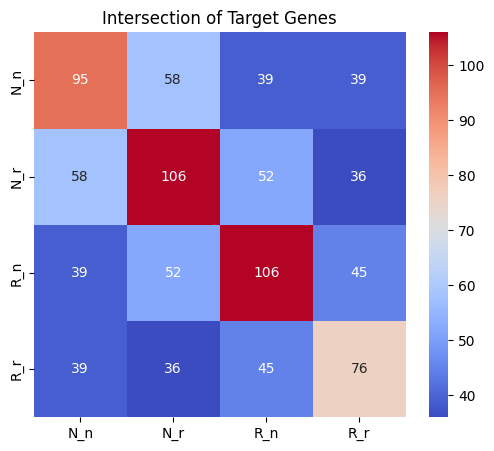

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Example sets of genes
set_names = ["N_n", "N_r", "R_n", "R_r"]
set_A = Nlog_nlog_target_set
set_B = Nlog_reciprocal_target_set
set_C = Reciprocal_nlog_target_set
set_D = Reciprocal_reciprocal_target_set

sets = [set_A, set_B, set_C, set_D]

# Step 2–3: Compute intersection matrix
intersection_matrix = np.zeros((4, 4), dtype=int)
for i in range(4):
    for j in range(4):
        intersection_matrix[i][j] = len(sets[i] & sets[j])

# Step 4: Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(intersection_matrix, annot=True, fmt="d", cmap="coolwarm", xticklabels=set_names, yticklabels=set_names)
plt.title("Intersection of Target Genes")
plt.show()

In [28]:
len(Nlog_nlog_target_set | Nlog_reciprocal_target_set | Reciprocal_nlog_target_set | Reciprocal_reciprocal_target_set)

210

see how the union of 4 methods' target genes perform

In [34]:
total_target_set = Nlog_nlog_target_set | Nlog_reciprocal_target_set | Reciprocal_nlog_target_set | Reciprocal_reciprocal_target_set

# Define your variables
N = len(background_set)  # Total genes in the universe
K = len(curated_set & background_set)   # Genes in the curated list
n = len(total_target_set)    # Genes in your prediction set
x = len(total_target_set & curated_set & background_set)     # Overlapping genes

# Calculate the p-value for enrichment
p_value = hypergeom.sf(x-1, N, K, n)  # sf = 1 - cdf
print("P-value:", p_value)

P-value: 0.14273852451933924


transition set genes

In [29]:
# Define your variables
N = len(background_set)  # Total genes in the universe
K = len(curated_set & background_set)   # Genes in the curated list
n = len(Nlog_nlog_transitional_set)    # Genes in your prediction set
x = len(Nlog_nlog_transitional_set & curated_set & background_set)     # Overlapping genes

# Calculate the p-value for enrichment
p_value = hypergeom.sf(x-1, N, K, n)  # sf = 1 - cdf
print("P-value:", p_value)

P-value: 0.8934039556258038


In [30]:
# Define your variables
N = len(background_set)  # Total genes in the universe
K = len(curated_set & background_set)   # Genes in the curated list
n = len(Nlog_reciprocal_transitional_set)    # Genes in your prediction set
x = len(Nlog_reciprocal_transitional_set & curated_set & background_set)     # Overlapping genes

# Calculate the p-value for enrichment
p_value = hypergeom.sf(x-1, N, K, n)  # sf = 1 - cdf
print("P-value:", p_value)

P-value: 0.6208946159977076


In [31]:
# Define your variables
N = len(background_set)  # Total genes in the universe
K = len(curated_set & background_set)   # Genes in the curated list
n = len(Reciprocal_nlog_transitional_set)    # Genes in your prediction set
x = len(Reciprocal_nlog_transitional_set & curated_set & background_set)     # Overlapping genes

# Calculate the p-value for enrichment
p_value = hypergeom.sf(x-1, N, K, n)  # sf = 1 - cdf
print("P-value:", p_value)

P-value: 0.5557331066652311


In [32]:
# Define your variables
N = len(background_set)  # Total genes in the universe
K = len(curated_set & background_set)   # Genes in the curated list
n = len(Reciprocal_reciprocal_transitional_set)    # Genes in your prediction set
x = len(Reciprocal_reciprocal_transitional_set & curated_set & background_set)     # Overlapping genes

# Calculate the p-value for enrichment
p_value = hypergeom.sf(x-1, N, K, n)  # sf = 1 - cdf
print("P-value:", p_value)

P-value: 0.5799347771981782


DEGs

In [33]:
# Define your variables
N = len(background_set)  # Total genes in the universe
K = len(curated_set & background_set)   # Genes in the curated list
n = len(deg_set)    # Genes in your prediction set
x = len(deg_set & curated_set & background_set)     # Overlapping genes

# Calculate the p-value for enrichment
p_value = hypergeom.sf(x-1, N, K, n)  # sf = 1 - cdf
print("P-value:", p_value)

P-value: 0.6399001521424049
